In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)

ROOT      = Path('..').resolve()
GOLD_PATH = ROOT / 'data' / 'gold' / 'model_dataset_monthly.csv'
FIG_DIR   = ROOT / 'outputs' / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(GOLD_PATH, parse_dates=['month'], index_col='month')
df.index.freq = 'MS'
print(f'Gold dataset : {df.shape}')
print(f'Plage : {df.index.min().date()} → {df.index.max().date()}')
print(f'Splits : {df["split_label"].value_counts().to_dict()}')

plt.rcParams.update({'figure.dpi': 120, 'font.size': 10, 'axes.grid': True, 'grid.alpha': 0.3})
sns.set_palette('Set2')

Gold dataset : (96, 45)
Plage : 2017-01-01 → 2024-12-01
Splits : {'train_A|train_B': 36, 'test_B': 36, 'test_A|train_B': 24}


In [2]:
# ── Tests de stationnarité sur ipc_level ──────────────────────────────────────
series = df['ipc_level'].dropna()

def stationarity_report(s, name='série'):
    adf_stat, adf_p, _, _, adf_crit, _ = adfuller(s, autolag='AIC')
    try:
        kpss_stat, kpss_p, _, kpss_crit = kpss(s, regression='c', nlags='auto')
        kpss_ok = kpss_p > 0.05
    except Exception:
        kpss_p, kpss_ok = None, None
    adf_ok = adf_p < 0.05
    print(f'--- {name} ---')
    print(f'  ADF  : stat={adf_stat:.3f}  p={adf_p:.4f}  → {"stationn." if adf_ok else "NON stationn."}')
    if kpss_p is not None:
        print(f'  KPSS : stat={kpss_stat:.3f}  p={kpss_p:.4f}  → {"stationn." if kpss_ok else "NON stationn."}')
    stationn = adf_ok and (kpss_ok if kpss_ok is not None else True)
    print(f'  => Conclusion : {"STATIONNAIRE" if stationn else "NON STATIONNAIRE"}')
    return adf_p, kpss_p

print('=== STATIONNARITE IPC ===\n')
stationarity_report(series, 'ipc_level (niveau)')
print()
diff1 = series.diff().dropna()
stationarity_report(diff1, 'diff(ipc_level, 1)')
print()
if 'inflation_yoy' in df.columns:
    yoy = df['inflation_yoy'].dropna()
    stationarity_report(yoy, 'inflation_yoy')

=== STATIONNARITE IPC ===

--- ipc_level (niveau) ---
  ADF  : stat=-0.448  p=0.9018  → NON stationn.
  KPSS : stat=1.365  p=0.0100  → NON stationn.
  => Conclusion : NON STATIONNAIRE

--- diff(ipc_level, 1) ---
  ADF  : stat=-2.579  p=0.0975  → NON stationn.
  KPSS : stat=0.254  p=0.1000  → stationn.
  => Conclusion : NON STATIONNAIRE

--- inflation_yoy ---
  ADF  : stat=-1.745  p=0.4081  → NON stationn.
  KPSS : stat=0.480  p=0.0463  → NON stationn.
  => Conclusion : NON STATIONNAIRE


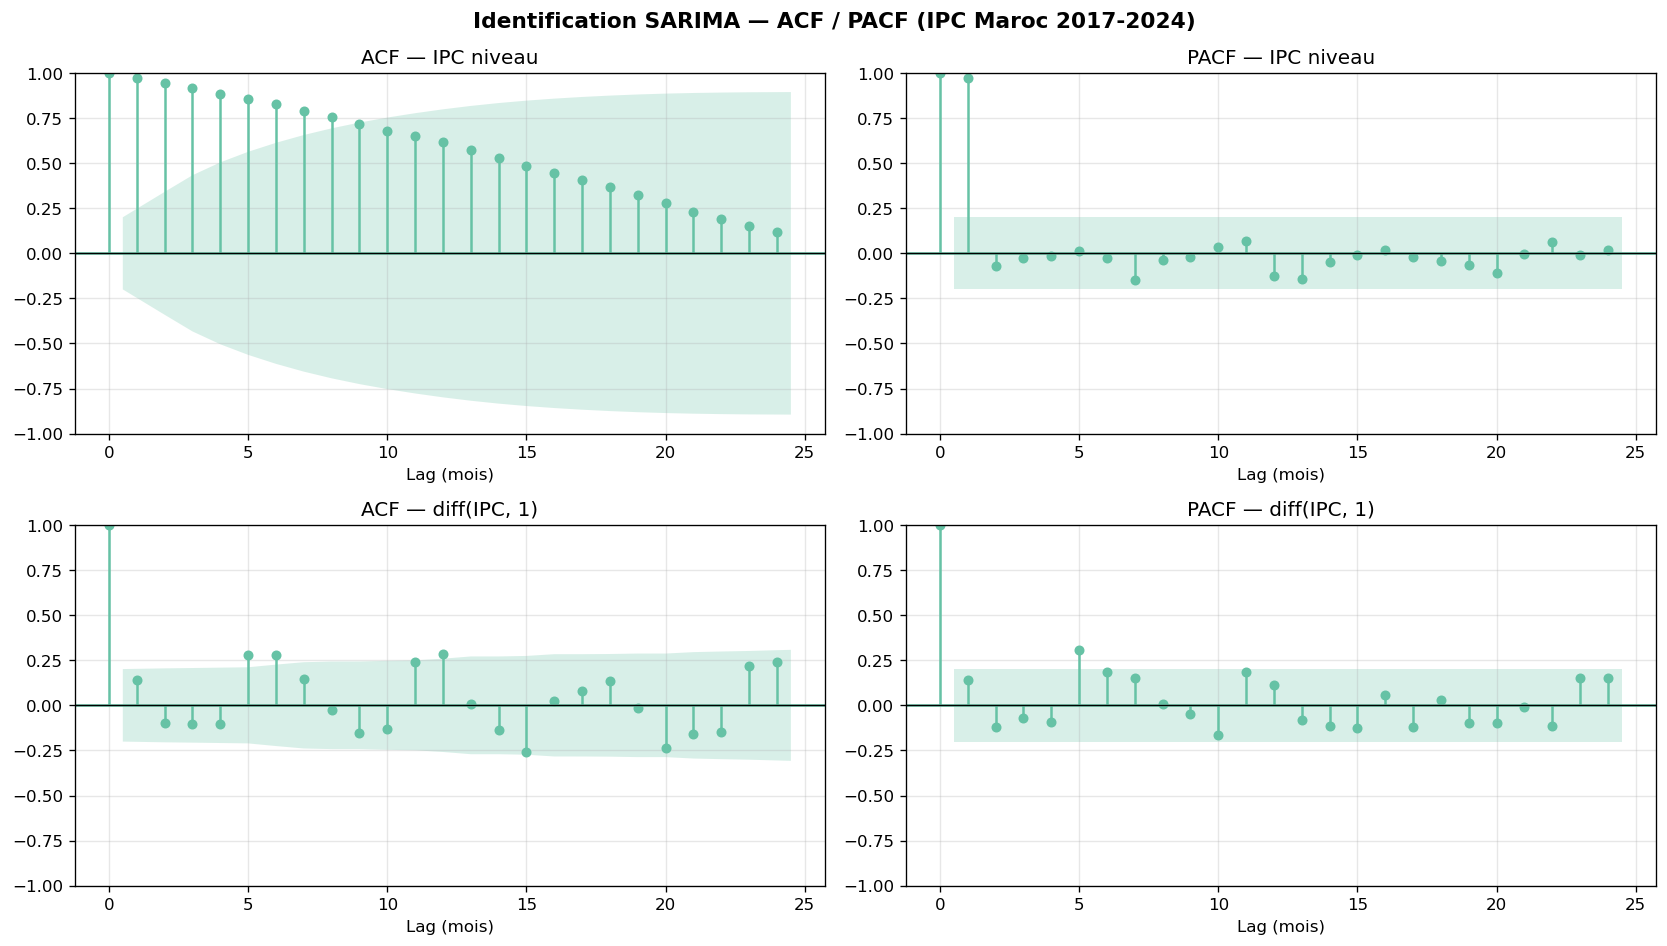

Figure sauvegardee : acf_pacf_v3.png


In [3]:
# ── ACF / PACF : identification SARIMA ──────────────────────────────────────
series_diff = df['ipc_level'].dropna().diff().dropna()

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Niveau
plot_acf(df['ipc_level'].dropna(),  lags=24, ax=axes[0, 0], title='ACF — IPC niveau')
plot_pacf(df['ipc_level'].dropna(), lags=24, ax=axes[0, 1], title='PACF — IPC niveau', method='ywm')

# Différencié
plot_acf(series_diff,  lags=24, ax=axes[1, 0], title='ACF — diff(IPC, 1)')
plot_pacf(series_diff, lags=24, ax=axes[1, 1], title='PACF — diff(IPC, 1)', method='ywm')

for ax in axes.flat:
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_xlabel('Lag (mois)')

plt.suptitle('Identification SARIMA — ACF / PACF (IPC Maroc 2017-2024)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'acf_pacf_v3.png', bbox_inches='tight')
plt.show()
print('Figure sauvegardee : acf_pacf_v3.png')

In [4]:
# ── Ajustement SARIMA(1,1,1)(1,0,1)[12] sur le train A ──────────────────────
# Train A = données avant 2020 (bloc train_A|train_B)
train_mask = df['split_label'].str.contains('train_A')
train_df   = df[train_mask].copy()
test_a_mask = df['split_label'].str.contains('test_A')
test_a_df   = df[test_a_mask].copy()

ipc_train = train_df['ipc_level'].dropna()
print(f'Train A : {len(ipc_train)} mois ({ipc_train.index.min().date()} → {ipc_train.index.max().date()})')

# Ajustement SARIMA
sarima = SARIMAX(ipc_train, order=(1,1,1), seasonal_order=(1,0,1,12),
                  enforce_stationarity=False, enforce_invertibility=False)
sarima_fit = sarima.fit(disp=False)

print(f'\nSARIMA(1,1,1)(1,0,1)[12] sur Train A')
print(f'  AIC  = {sarima_fit.aic:.2f}')
print(f'  BIC  = {sarima_fit.bic:.2f}')
print(f'  HQIC = {sarima_fit.hqic:.2f}')
print()
print(sarima_fit.summary().tables[1])

Train A : 36 mois (2017-01-01 → 2019-12-01)



SARIMA(1,1,1)(1,0,1)[12] sur Train A
  AIC  = 64.85
  BIC  = 70.08
  HQIC = 65.99

                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1213      3.128      0.039      0.969      -6.010       6.253
ma.L1         -0.1258      3.038     -0.041      0.967      -6.081       5.829
ar.S.L12       0.8199      0.215      3.819      0.000       0.399       1.241
ma.S.L12      -0.1936      0.354     -0.546      0.585      -0.888       0.501
sigma2         0.7821      0.334      2.342      0.019       0.128       1.437


In [5]:
# ── Ajustement SARIMAX + behavioral_index_pure ──────────────────────────────
exog_col = 'behavioral_index_pure_lag1'
if exog_col not in train_df.columns:
    print(f'Colonne {exog_col} absente — SARIMAX non disponible')
else:
    exog_train = train_df[exog_col].fillna(method='ffill').dropna()
    ipc_train_x = ipc_train.reindex(exog_train.index).dropna()
    exog_train_x = exog_train.reindex(ipc_train_x.index)

    sarimax = SARIMAX(ipc_train_x, exog=exog_train_x, order=(1,1,1), seasonal_order=(1,0,1,12),
                       enforce_stationarity=False, enforce_invertibility=False)
    sarimax_fit = sarimax.fit(disp=False)

    print(f'SARIMAX(1,1,1)(1,0,1)[12] + {exog_col} sur Train A')
    print(f'  AIC  = {sarimax_fit.aic:.2f}  (SARIMA : {sarima_fit.aic:.2f}  | delta={sarimax_fit.aic - sarima_fit.aic:+.2f})')
    print(f'  BIC  = {sarimax_fit.bic:.2f}  (SARIMA : {sarima_fit.bic:.2f}  | delta={sarimax_fit.bic - sarima_fit.bic:+.2f})')
    print()
    print(sarimax_fit.summary().tables[1])
    print()
    coef_beh = sarimax_fit.params.get(exog_col, None)
    pval_beh = sarimax_fit.pvalues.get(exog_col, None)
    if coef_beh is not None:
        sig = '** SIGNIFICATIF **' if pval_beh < 0.05 else f'(p={pval_beh:.3f}, non sig.)'
        print(f'  Coefficient BESI behavioral : {coef_beh:.4f}  {sig}')

SARIMAX(1,1,1)(1,0,1)[12] + behavioral_index_pure_lag1 sur Train A
  AIC  = 57.09  (SARIMA : 64.85  | delta=-7.77)
  BIC  = 63.06  (SARIMA : 70.08  | delta=-7.01)

                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
behavioral_index_pure_lag1     8.6115      1.768      4.870      0.000       5.145      12.078
ar.L1                         -0.2888      0.218     -1.326      0.185      -0.716       0.138
ma.L1                          1.0000   9871.815      0.000      1.000   -1.93e+04    1.93e+04
ar.S.L12                       0.3827      0.241      1.589      0.112      -0.089       0.855
ma.S.L12                       1.0001   6864.481      0.000      1.000   -1.35e+04    1.35e+04
sigma2                         0.2909   3626.335   8.02e-05      1.000   -7107.195    7107.777

  Coefficient BESI behavioral : 8.6115  ** SIGNIFICATIF **


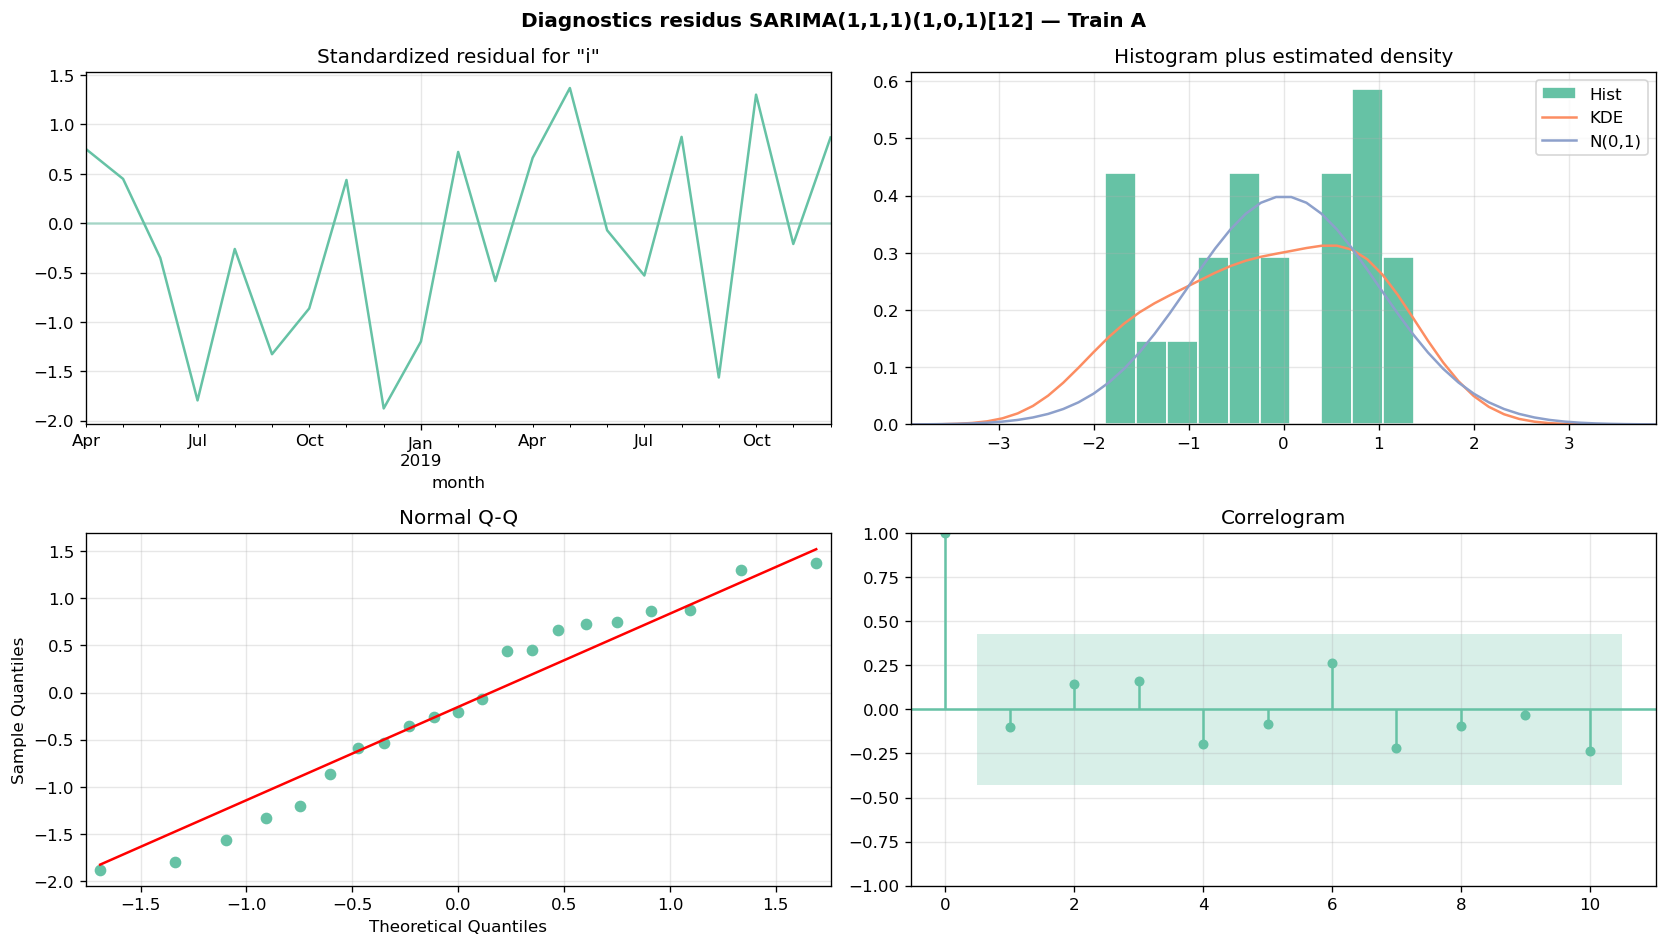

Figure sauvegardee : residuals_sarima_v3.png


In [6]:
# ── Residus diagnostics SARIMA ────────────────────────────────────────────────
fig = sarima_fit.plot_diagnostics(figsize=(14, 8))
plt.suptitle('Diagnostics residus SARIMA(1,1,1)(1,0,1)[12] — Train A', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'residuals_sarima_v3.png', bbox_inches='tight')
plt.show()
print('Figure sauvegardee : residuals_sarima_v3.png')

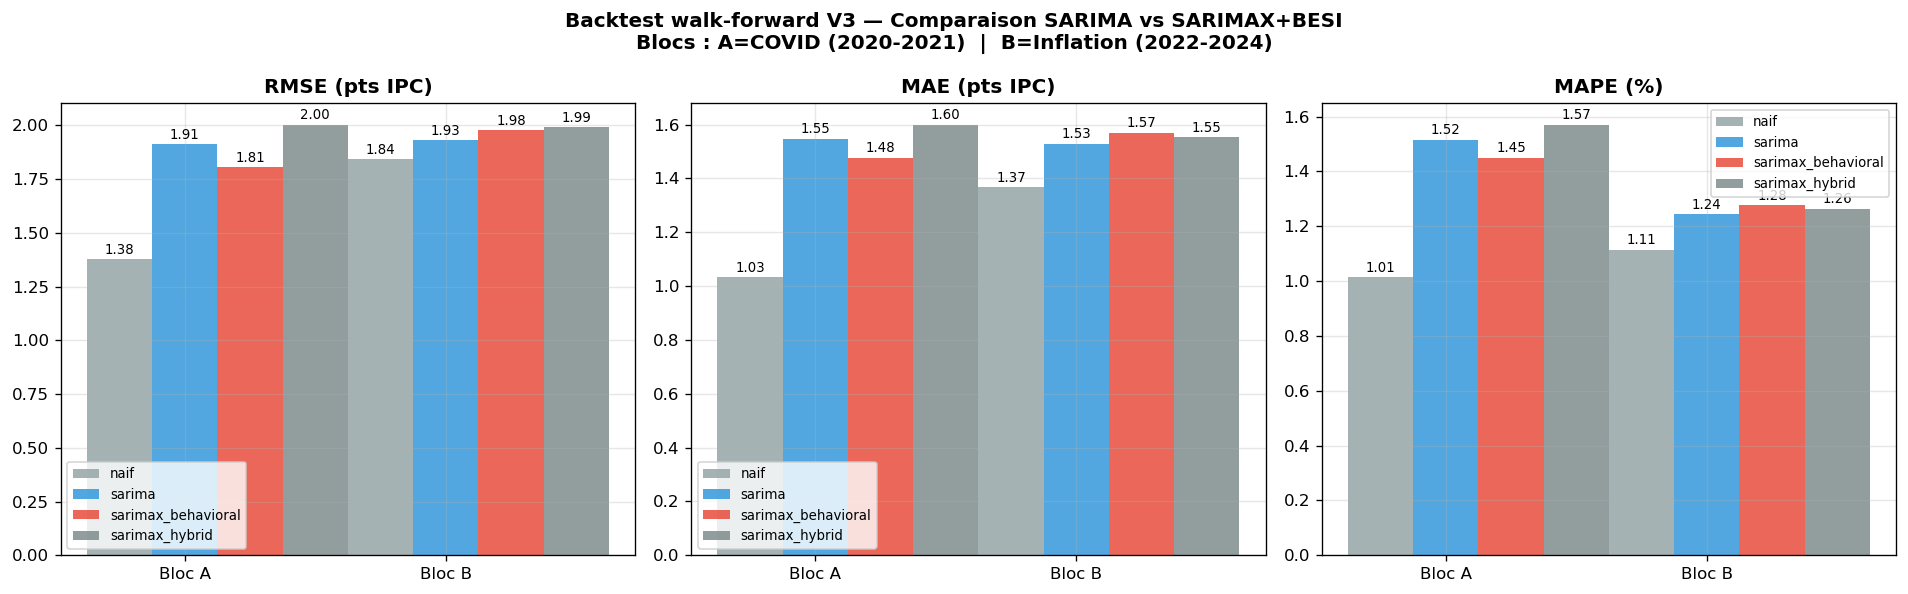


Tableau synthetique :
                     rmse    mae   mape
model                                  
naif               1.6094 1.2000 1.0635
sarimax_behavioral 1.8914 1.5225 1.3629
sarima             1.9227 1.5373 1.3796
sarimax_hybrid     1.9974 1.5765 1.4172


In [7]:
# ── Visualisation des resultats du backtest walk-forward ────────────────────
backtest_path = ROOT / 'outputs' / 'reports' / 'backtest_v3_results.csv'
bt = pd.read_csv(backtest_path)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metrics = ['rmse', 'mae', 'mape']
labels  = ['RMSE (pts IPC)', 'MAE (pts IPC)', 'MAPE (%)']
colors  = {'naif': '#95a5a6', 'sarima': '#3498db', 'sarimax_behavioral': '#e74c3c'}

for ax, metric, label in zip(axes, metrics, labels):
    pivot = bt.pivot(index='model', columns='bloc', values=metric)
    x = np.arange(len(pivot.columns))
    width = 0.25
    for i, (model, row) in enumerate(pivot.iterrows()):
        color = colors.get(model, '#7f8c8d')
        bars = ax.bar(x + i * width, row.values, width, label=model, color=color, alpha=0.85)
        for bar in bars:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                    f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=8)
    ax.set_xticks(x + width)
    ax.set_xticklabels([f'Bloc {b}' for b in pivot.columns])
    ax.set_title(label, fontweight='bold')
    ax.legend(fontsize=8)
    ax.set_ylim(bottom=0)

plt.suptitle('Backtest walk-forward V3 — Comparaison SARIMA vs SARIMAX+BESI\n'
             'Blocs : A=COVID (2020-2021)  |  B=Inflation (2022-2024)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'backtest_v3_bar_comparison.png', bbox_inches='tight')
plt.show()

print('\nTableau synthetique :')
summary = bt.groupby('model')[['rmse','mae','mape']].mean().sort_values('rmse')
print(summary.to_string(float_format='{:.4f}'.format))